In [ ]:
%pip install ucimlrepo pandas scikit-learn matplotlib seaborn numpy

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

: 

2. Tabular data ingestion (Heart Disease)


In [ ]:
# Fetch UCI Heart Disease dataset
heart_disease = fetch_ucirepo(id=45)

# Features
X = heart_disease.data.features.copy()

# Target
y = heart_disease.data.targets.copy()

# Metadata
print("Dataset Metadata:")
print(heart_disease.metadata)

print("\nVariable Information:")
print(heart_disease.variables)

Dataset Metadata:
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi

Inspecting the dataset


In [ ]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFirst 5 rows of features:")
display(X.head())

print("\nTarget:")
display(y.head())

print("\nMissing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Feature Shape: (303, 13)
Target Shape: (303, 1)

First 5 rows of features:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Target:


,num
0,0
1,2
2,1
3,0
4,0



Missing values in features:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Missing values in target:
num    0
dtype: int64


Convert target to binary classification


Binary Target Distribution:
num
0    164
1    139
Name: count, dtype: int64


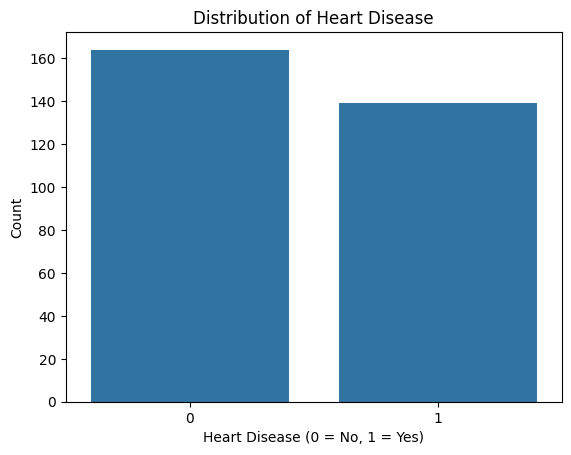

In [ ]:
# Convert target DataFrame to Series
y = y.iloc[:, 0]

# 0 = No disease
# 1, 2, 3, 4 = Disease present
y = (y > 0).astype(int)

print("Binary Target Distribution:")
print(y.value_counts())

sns.countplot(x=y)
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Combine Features and Target for EDA


In [ ]:
df = X.copy()
df["target"] = y

display(df.head())

print(df.info())

print(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.68976

Check Missing Values


In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
ca      4
thal    2
dtype: int64


Feature Distribution Visualization


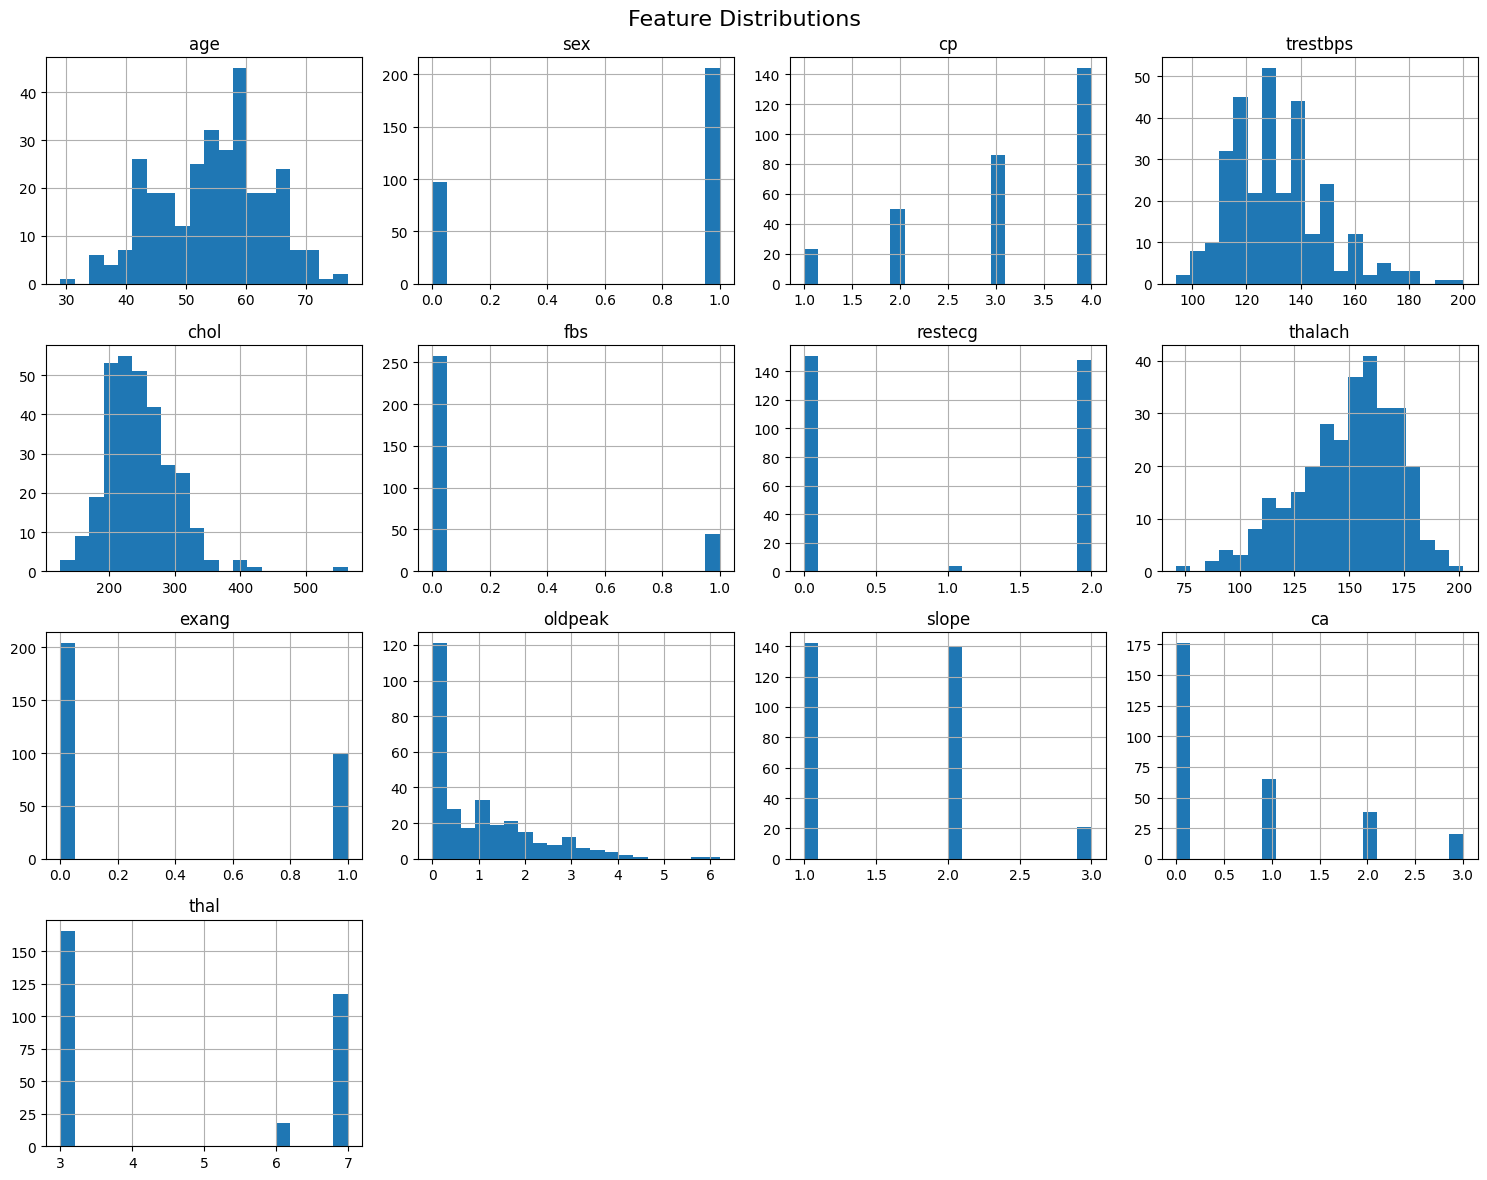

In [ ]:
X.hist(figsize=(15, 12), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

Correlation Heatmap


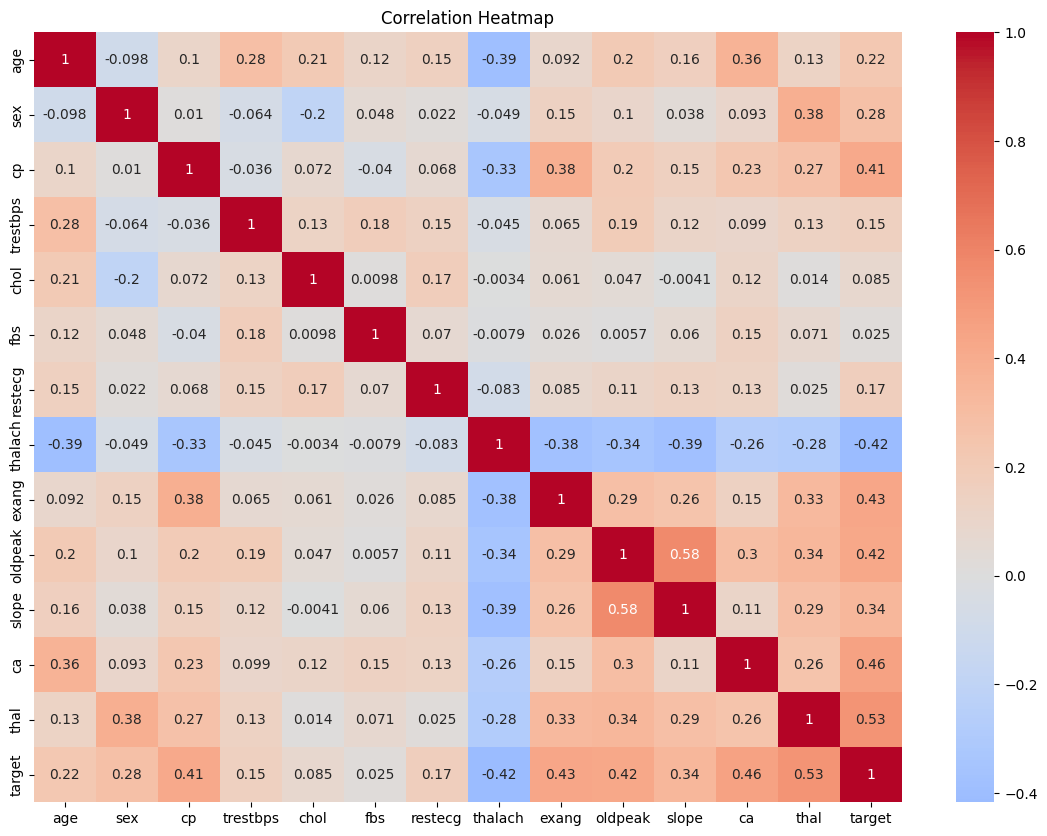

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

Prepare Data for Machine Learning


In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (303, 13)
y Shape: (303,)


Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 242
Testing Samples: 61


Handle Missing Values and Scale Features


In [ ]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])

Train the Logistic Regression Model


In [ ]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


Make Predictions


In [ ]:
y_pred = model.predict(X_test)

# Probability of heart disease
y_prob = model.predict_proba(X_test)[:, 1]

Evaluate the Model

Accuracy


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8689


ROC-AUC Score


In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9513


Classification Report


In [ ]:
print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
))

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



Confusion Matrix


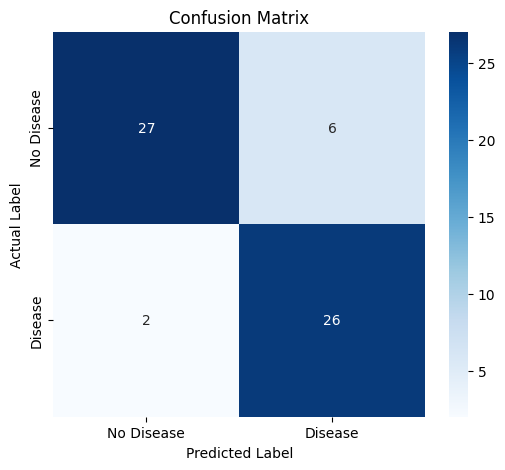

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

ROC Curve


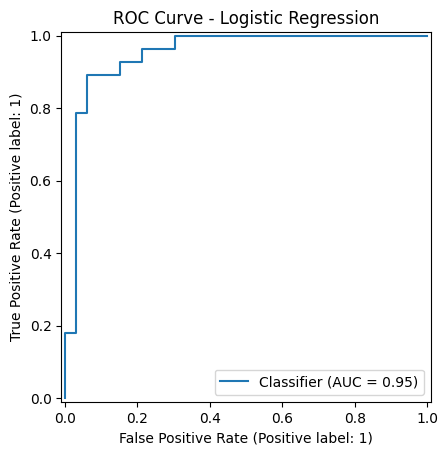

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Logistic Regression")
plt.show()

In [ ]:
print("=" * 50)
print("HEART DISEASE PREDICTION RESULTS")
print("=" * 50)

print(f"\nAccuracy Score : {accuracy:.4f}")
print(f"ROC-AUC Score  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Disease", "Disease"]
))

HEART DISEASE PREDICTION RESULTS

Accuracy Score : 0.8689
ROC-AUC Score  : 0.9513

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.93      0.82      0.87        33
     Disease       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



3. Signal data ingestion (ECG)


In [ ]:
!pip install wfdb numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.7 MB/s eta 0:00:00


In [ ]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load MIT-BIH Record 100


In [ ]:
record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

In [ ]:
print("Signal Shape:", record.p_signal.shape)
print("Sampling Frequency:", record.fs)
print("Signal Names:", record.sig_name)

print("\nFirst 10 annotation samples:")
print(annotation.sample[:10])

print("\nFirst 10 annotation symbols:")
print(annotation.symbol[:10])

Signal Shape: (650000, 2)
Sampling Frequency: 360
Signal Names: ['MLII', 'V5']

First 10 annotation samples:
[  18   77  370  662  946 1231 1515 1809 2044 2402]

First 10 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


Extract the ECG Signal


In [ ]:
ecg_signal = record.p_signal[:, 0]

fs = record.fs

print("Total number of samples:", len(ecg_signal))
print("Duration in seconds:", len(ecg_signal) / fs)

Total number of samples: 650000
Duration in seconds: 1805.5555555555557


Plot a Segment of the ECG Waveform


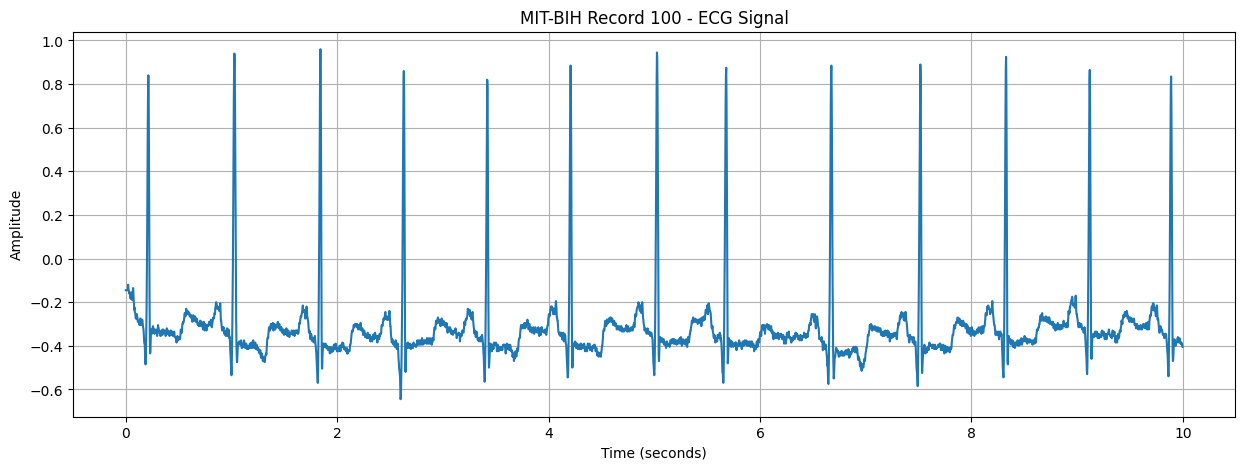

In [ ]:
start_time = 0
duration = 10

start_sample = int(start_time * fs)
end_sample = int((start_time + duration) * fs)

time = np.arange(start_sample, end_sample) / fs

plt.figure(figsize=(15, 5))

plt.plot(
    time,
    ecg_signal[start_sample:end_sample]
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("MIT-BIH Record 100 - ECG Signal")

plt.grid(True)
plt.show()

Plot ECG Waveform with Beat Annotations


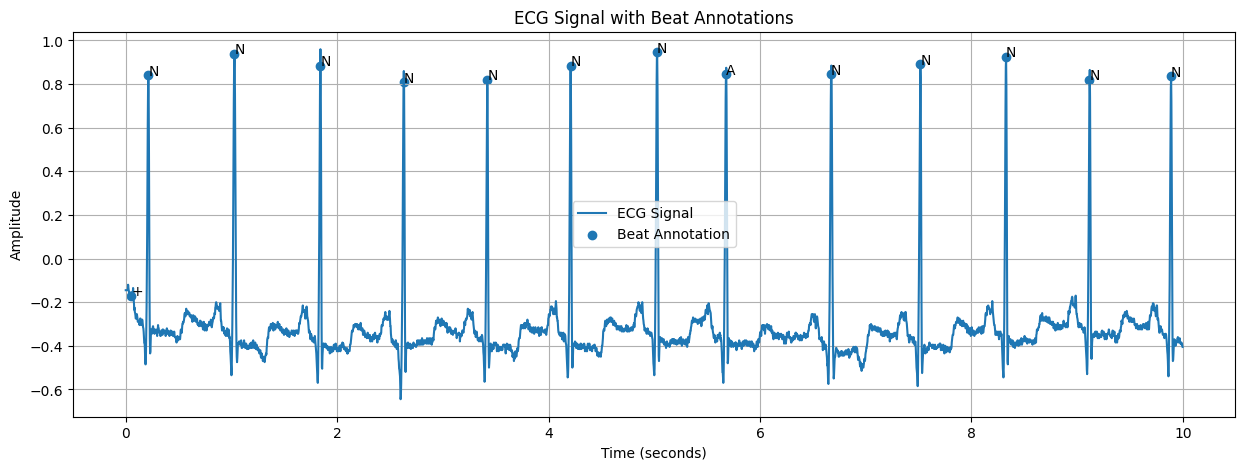

In [ ]:
# Get all annotation sample locations
ann_samples = annotation.sample

# Get corresponding annotation symbols
ann_symbols = annotation.symbol

# Find annotations within selected segment
mask = (
    (ann_samples >= start_sample) &
    (ann_samples < end_sample)
)

segment_ann_samples = ann_samples[mask]
segment_ann_symbols = np.array(ann_symbols)[mask]

# Convert annotation sample positions to time
segment_ann_times = segment_ann_samples / fs

# ECG amplitude at annotation positions
segment_ann_amplitudes = ecg_signal[segment_ann_samples]

plt.figure(figsize=(15, 5))

# Plot ECG waveform
plt.plot(
    time,
    ecg_signal[start_sample:end_sample],
    label="ECG Signal"
)

# Plot beat locations
plt.scatter(
    segment_ann_times,
    segment_ann_amplitudes,
    marker="o",
    label="Beat Annotation"
)

# Add beat symbols
for x, y, symbol in zip(
    segment_ann_times,
    segment_ann_amplitudes,
    segment_ann_symbols
):
    plt.text(
        x,
        y,
        symbol,
        fontsize=10
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("ECG Signal with Beat Annotations")

plt.legend()
plt.grid(True)

plt.show()

Create a Beat Annotation DataFrame


In [ ]:
annotations_df = pd.DataFrame({
    "sample": annotation.sample,
    "time_seconds": annotation.sample / fs,
    "beat_type": annotation.symbol
})

display(annotations_df.head(20))

,sample,time_seconds,beat_type
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


In [ ]:
beat_counts = annotations_df["beat_type"].value_counts()

print(beat_counts)

beat_type
N    2239
A      33
+       1
V       1
Name: count, dtype: int64


Extract Beat-to-Beat Intervals


In [ ]:
normal_beat_samples = annotations_df[
    annotations_df["beat_type"] == "N"
]["sample"].values

print("Number of normal beats:", len(normal_beat_samples))

Number of normal beats: 2239


Compute RR intervals:


In [ ]:
rr_intervals = np.diff(normal_beat_samples) / fs

print("First 10 RR intervals:")
print(rr_intervals[:10])

First 10 RR intervals:
[0.81388889 0.81111111 0.78888889 0.79166667 0.78888889 0.81666667
 1.64722222 0.84444444 0.81111111 0.78888889]


Compute Basic Heart Rate Statistics


Heart rate can be estimated from the RR interval:

HR=
RR /
60
​


In [ ]:
heart_rate = 60 / rr_intervals

print("Mean Heart Rate:", np.mean(heart_rate))
print("Median Heart Rate:", np.median(heart_rate))
print("Minimum Heart Rate:", np.min(heart_rate))
print("Maximum Heart Rate:", np.max(heart_rate))

Mean Heart Rate: 75.06490288963278
Median Heart Rate: 75.26132404181185
Minimum Heart Rate: 36.0
Maximum Heart Rate: 91.91489361702128


In [ ]:
print("=" * 45)
print("HEART RATE ANALYSIS")
print("=" * 45)

print(f"Number of Normal Beats: {len(normal_beat_samples)}")
print(f"Number of RR Intervals: {len(rr_intervals)}")

print(f"\nMean RR Interval: {np.mean(rr_intervals):.3f} seconds")
print(f"Standard Deviation of RR: {np.std(rr_intervals):.3f} seconds")

print(f"\nMean Heart Rate: {np.mean(heart_rate):.2f} BPM")
print(f"Median Heart Rate: {np.median(heart_rate):.2f} BPM")
print(f"Minimum Heart Rate: {np.min(heart_rate):.2f} BPM")
print(f"Maximum Heart Rate: {np.max(heart_rate):.2f} BPM")

HEART RATE ANALYSIS
Number of Normal Beats: 2239
Number of RR Intervals: 2238

Mean RR Interval: 0.807 seconds
Standard Deviation of RR: 0.101 seconds

Mean Heart Rate: 75.06 BPM
Median Heart Rate: 75.26 BPM
Minimum Heart Rate: 36.00 BPM
Maximum Heart Rate: 91.91 BPM


Compute Basic HRV Statistics


Two common simple HRV measures are SDNN and RMSSD.


SDNN

Standard deviation of RR intervals:


In [ ]:
sdnn = np.std(rr_intervals, ddof=1)

print(f"SDNN: {sdnn:.4f} seconds")

SDNN: 0.1007 seconds


RMSSD

Root Mean Square of Successive Differences:


In [ ]:
successive_diff = np.diff(rr_intervals)

rmssd = np.sqrt(
    np.mean(successive_diff ** 2)
)

print(f"RMSSD: {rmssd:.4f} seconds")

RMSSD: 0.1334 seconds


Combined:


In [ ]:
print("=" * 45)
print("BASIC HRV STATISTICS")
print("=" * 45)

print(f"Mean RR Interval: {np.mean(rr_intervals):.4f} sec")
print(f"SDNN: {sdnn:.4f} sec")
print(f"RMSSD: {rmssd:.4f} sec")

BASIC HRV STATISTICS
Mean RR Interval: 0.8067 sec
SDNN: 0.1007 sec
RMSSD: 0.1334 sec


Visualize RR Intervals


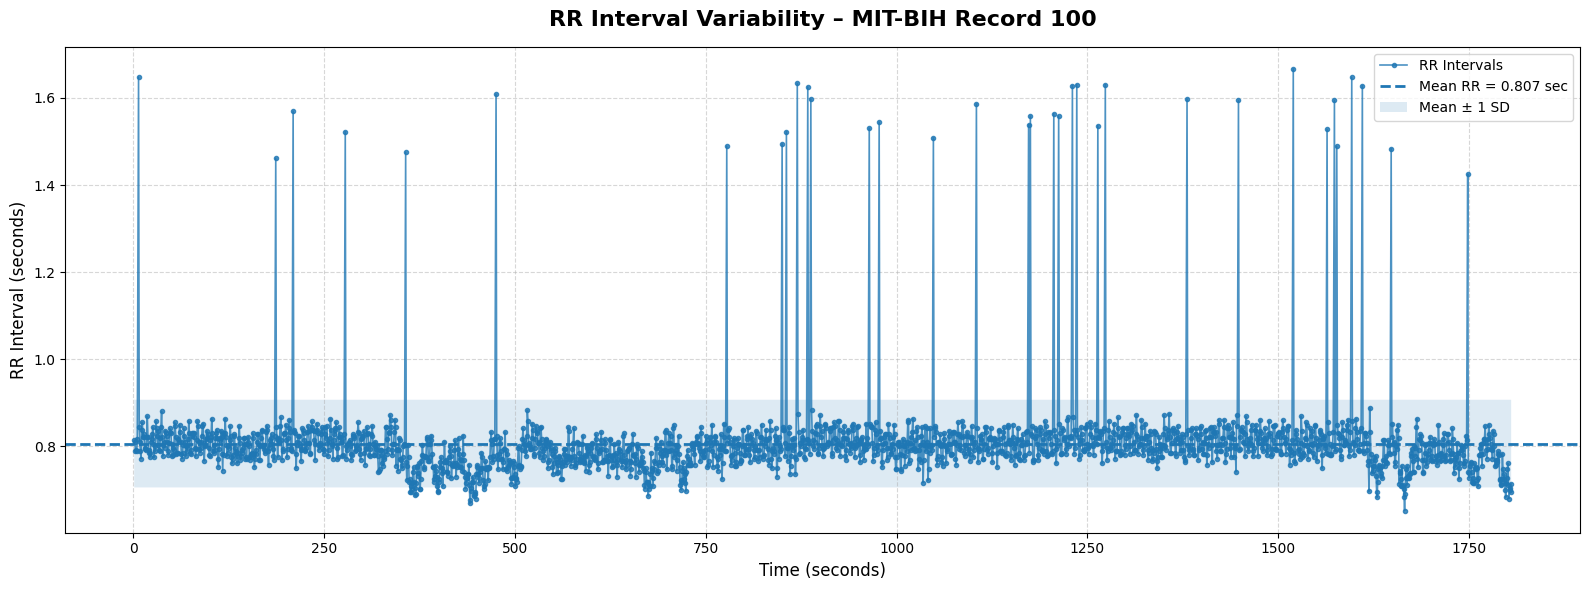

In [ ]:
# Time location of each RR interval
rr_times = normal_beat_samples[1:] / fs

# Basic statistics
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals, ddof=1)

# Create the plot
plt.figure(figsize=(16, 6))

# RR interval trend
plt.plot(
    rr_times,
    rr_intervals,
    marker="o",
    markersize=3,
    linewidth=1.2,
    alpha=0.8,
    label="RR Intervals"
)

# Mean RR interval
plt.axhline(
    mean_rr,
    linestyle="--",
    linewidth=2,
    label=f"Mean RR = {mean_rr:.3f} sec"
)

# Mean ± 1 Standard Deviation
plt.fill_between(
    rr_times,
    mean_rr - std_rr,
    mean_rr + std_rr,
    alpha=0.15,
    label="Mean ± 1 SD"
)

# Labels and formatting
plt.title(
    "RR Interval Variability – MIT-BIH Record 100",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Time (seconds)", fontsize=12)
plt.ylabel("RR Interval (seconds)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

4. Textual data demonstration


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving clinical_note.txt to clinical_note (1).txt


In [ ]:
with open("clinical_note.txt", "r", encoding="utf-8") as file:
    clinical_notes = file.read()

print("First 1000 characters:\n")
print(clinical_notes[:1000])

First 1000 characters:

SYNTHETIC CLINICAL NOTES FOR MULTIMODAL HEART DISEASE NLP DEMONSTRATION

NOTE 1
Patient ID: P001
A 58-year-old patient reports recurrent chest pain during physical activity.
The discomfort improves with rest and is associated with shortness of breath.
Medical history includes hypertension and elevated cholesterol. ECG evaluation
and further cardiac assessment are recommended.

NOTE 2
Patient ID: P002
A 64-year-old patient presents with intermittent chest discomfort and fatigue.
The patient reports occasional dizziness but denies symptoms at rest. History
includes hypertension and a family history of heart disease. Further evaluation
of cardiovascular risk factors is advised.

NOTE 3
Patient ID: P003
A 47-year-old patient reports palpitations and shortness of breath during
exercise. No persistent chest pain is reported. The patient has elevated blood
pressure and cholesterol. ECG monitoring is recommended.

NOTE 4



Text Cleaning and Tokenization


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Convert to lowercase
cleaned_text = clinical_notes.lower()

# Remove numbers and punctuation
cleaned_text = re.sub(r"[^a-z\s]", " ", cleaned_text)

# Remove extra spaces
cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

# Tokenization
tokens = cleaned_text.split()

print("Total Tokens:", len(tokens))
print("\nFirst 30 Tokens:")
print(tokens[:30])

Total Tokens: 579

First 30 Tokens:
['synthetic', 'clinical', 'notes', 'for', 'multimodal', 'heart', 'disease', 'nlp', 'demonstration', 'note', 'patient', 'id', 'p', 'a', 'year', 'old', 'patient', 'reports', 'recurrent', 'chest', 'pain', 'during', 'physical', 'activity', 'the', 'discomfort', 'improves', 'with', 'rest', 'and']


Remove Stopwords


In [ ]:
stopwords = {
    "a", "an", "the", "and", "or", "of", "in", "on",
    "with", "to", "for", "is", "are", "was", "were",
    "has", "have", "had", "this", "that", "these",
    "those", "during", "after", "before", "from",
    "as", "at", "by", "be", "being", "been",
    "patient", "reports", "report", "presents",
    "includes", "include", "history", "medical",
    "further", "recommended", "advised"
}

filtered_tokens = [
    word for word in tokens
    if word not in stopwords and len(word) > 2
]

print("Filtered Tokens:", len(filtered_tokens))
print("\nSample:")
print(filtered_tokens[:30])

Filtered Tokens: 300

Sample:
['synthetic', 'clinical', 'notes', 'multimodal', 'heart', 'disease', 'nlp', 'demonstration', 'note', 'year', 'old', 'recurrent', 'chest', 'pain', 'physical', 'activity', 'discomfort', 'improves', 'rest', 'associated', 'shortness', 'breath', 'hypertension', 'elevated', 'cholesterol', 'ecg', 'evaluation', 'cardiac', 'assessment', 'note']


Compute Word Frequency


In [ ]:
word_freq = Counter(filtered_tokens)

word_freq_df = pd.DataFrame(
    word_freq.items(),
    columns=["Word", "Frequency"]
)

word_freq_df = word_freq_df.sort_values(
    by="Frequency",
    ascending=False
).reset_index(drop=True)

display(word_freq_df.head(20))

,Word,Frequency
0,note,15
1,year,15
2,old,15
3,chest,15
4,pain,9
5,breath,9
6,hypertension,9
7,shortness,9
8,symptoms,9
9,cholesterol,8


Visualize the Top 15 Most Frequent Words


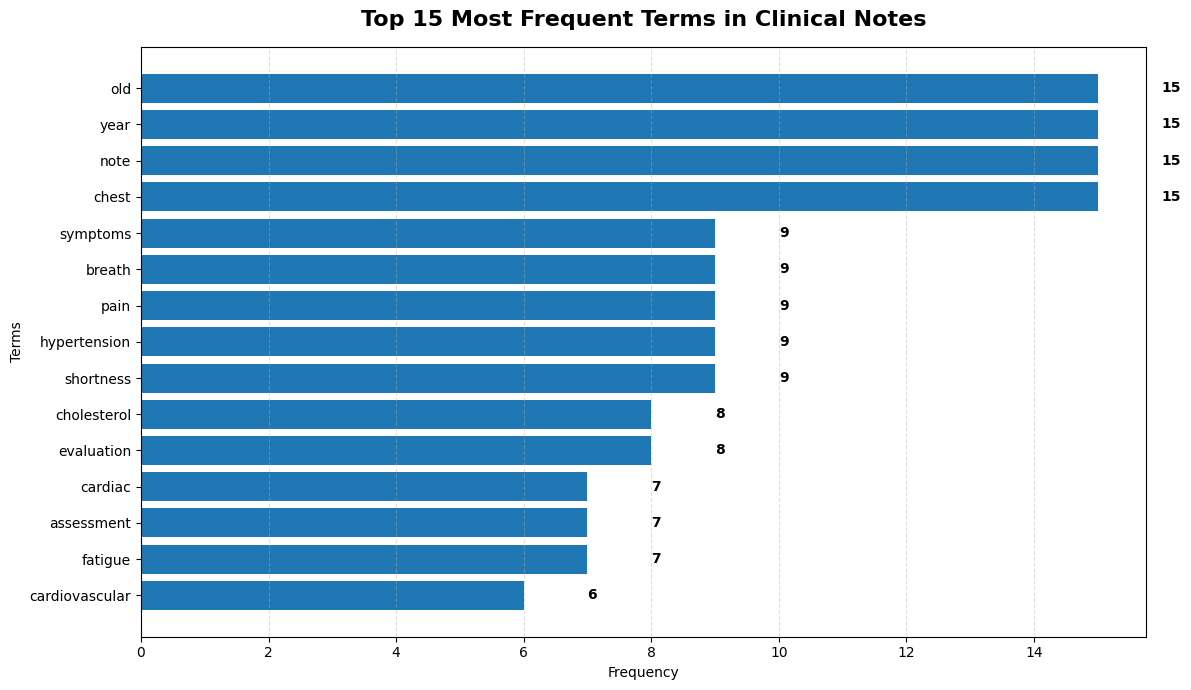

In [ ]:
top_words = word_freq_df.head(15).sort_values("Frequency")

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_words["Word"],
    top_words["Frequency"]
)

# Add frequency labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center",
        fontweight="bold"
    )

plt.title(
    "Top 15 Most Frequent Terms in Clinical Notes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Frequency")
plt.ylabel("Terms")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Extract Key Clinical Terms


In [ ]:
clinical_keywords = [
    "chest pain",
    "chest discomfort",
    "chest pressure",
    "chest tightness",
    "shortness of breath",
    "hypertension",
    "cholesterol",
    "fatigue",
    "dizziness",
    "palpitations",
    "diabetes",
    "ecg",
    "cardiac",
    "cardiovascular",
    "exercise tolerance"
]

Count how frequently each term occurs:


In [ ]:
note_lower = clinical_notes.lower()

clinical_term_counts = {
    term: note_lower.count(term)
    for term in clinical_keywords
}

# Convert to DataFrame
term_df = pd.DataFrame(
    clinical_term_counts.items(),
    columns=["Clinical Term", "Frequency"]
)

# Keep only detected terms
term_df = term_df[
    term_df["Frequency"] > 0
].sort_values(
    "Frequency",
    ascending=False
).reset_index(drop=True)

display(term_df)

,Clinical Term,Frequency
0,chest pain,9
1,hypertension,9
2,shortness of breath,8
3,cholesterol,8
4,fatigue,7
5,cardiac,7
6,ecg,6
7,cardiovascular,6
8,diabetes,4
9,chest discomfort,4


Visualize Extracted Clinical Terms


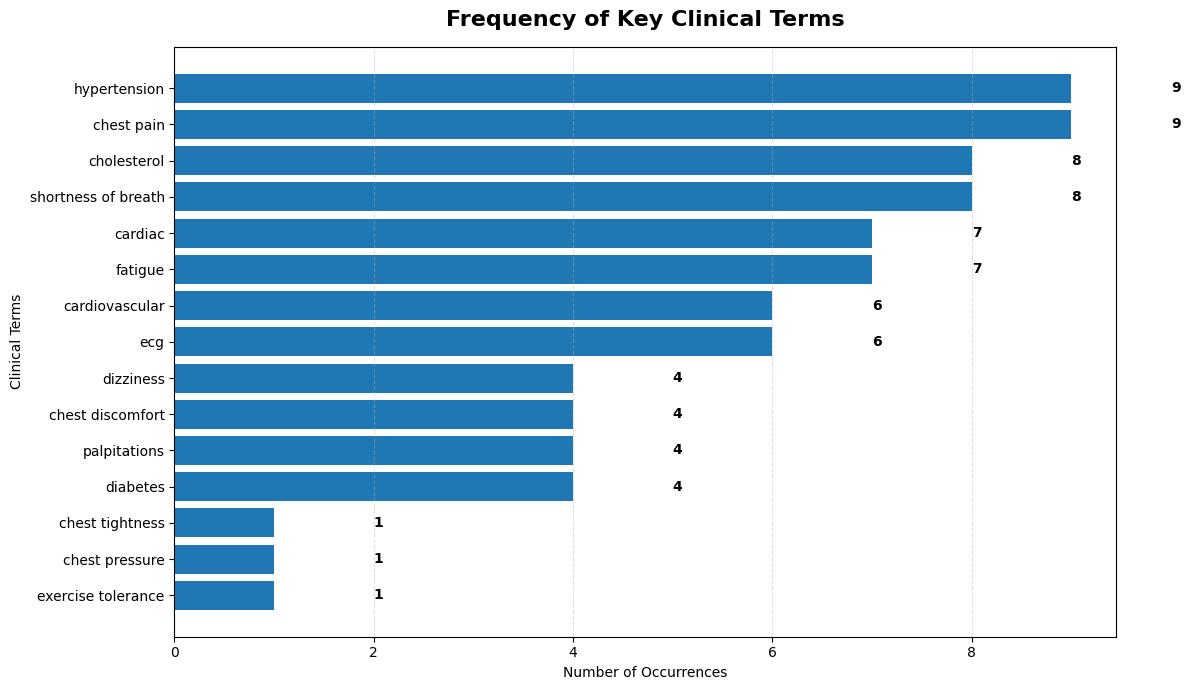

In [ ]:
plot_df = term_df.sort_values("Frequency")

plt.figure(figsize=(12, 7))

bars = plt.barh(
    plot_df["Clinical Term"],
    plot_df["Frequency"]
)

# Add value labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontweight="bold"
    )

plt.title(
    "Frequency of Key Clinical Terms",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Occurrences")
plt.ylabel("Clinical Terms")

plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

Simple Patient-Wise Key Term Extraction


In [ ]:
notes = re.split(r"NOTE \d+", clinical_notes)

notes = [
    note.strip()
    for note in notes
    if note.strip()
]

print(f"Total Patient Notes: {len(notes)}")

Total Patient Notes: 16


Extract the terms from each patient note:


In [ ]:
patient_results = []

for note in notes:

    # Extract Patient ID
    patient_id_match = re.search(
        r"Patient ID:\s*(P\d+)",
        note
    )

    patient_id = (
        patient_id_match.group(1)
        if patient_id_match
        else "Unknown"
    )

    # Find clinical keywords
    found_terms = [
        term
        for term in clinical_keywords
        if term in note.lower()
    ]

    patient_results.append({
        "Patient ID": patient_id,
        "Clinical Terms Detected": ", ".join(found_terms),
        "Number of Terms": len(found_terms)
    })

patient_df = pd.DataFrame(patient_results)

display(patient_df.head(10))

,Patient ID,Clinical Terms Detected,Number of Terms
0,Unknown,,0
1,P001,"chest pain, shortness of breath, hypertension,...",6
2,P002,"chest discomfort, hypertension, fatigue, dizzi...",5
3,P003,"chest pain, shortness of breath, cholesterol, ...",5
4,P004,"chest pain, shortness of breath, hypertension,...",6
5,P005,"chest discomfort, cholesterol, dizziness, cardiac",4
6,P006,"chest pain, shortness of breath, hypertension,...",7
7,P007,"chest pain, dizziness, palpitations, ecg",4
8,P008,"chest pressure, shortness of breath, hypertens...",6
9,P009,"chest pain, shortness of breath, fatigue, palp...",5


Final Summary


In [ ]:
print("=" * 55)
print("TEXTUAL DATA / SIMPLE NLP ANALYSIS SUMMARY")
print("=" * 55)

print(f"\nTotal Clinical Notes: {len(notes)}")
print(f"Total Tokens: {len(tokens)}")
print(f"Filtered Tokens: {len(filtered_tokens)}")
print(f"Unique Terms: {len(set(filtered_tokens))}")

print("\nTop 10 Most Frequent Words:")
for word, count in word_freq.most_common(10):
    print(f"{word:<20} : {count}")

print("\nTop Clinical Terms:")
print(term_df.head(10).to_string(index=False))

TEXTUAL DATA / SIMPLE NLP ANALYSIS SUMMARY

Total Clinical Notes: 16
Total Tokens: 579
Filtered Tokens: 300
Unique Terms: 93

Top 10 Most Frequent Words:
note                 : 15
year                 : 15
old                  : 15
chest                : 15
pain                 : 9
shortness            : 9
breath               : 9
hypertension         : 9
symptoms             : 9
cholesterol          : 8

Top Clinical Terms:
      Clinical Term  Frequency
         chest pain          9
       hypertension          9
shortness of breath          8
        cholesterol          8
            fatigue          7
            cardiac          7
                ecg          6
     cardiovascular          6
           diabetes          4
   chest discomfort          4


5. Image data demonstration


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving chest_xray.jpg to chest_xray.jpg


Load the Image Using Pillow


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
image = Image.open("chest_xray.jpg")

print("Image loaded successfully!")

Image loaded successfully!


Extract Image Metadata


In [ ]:
print("Image Format:", image.format)
print("Image Mode:", image.mode)
print("Image Size:", image.size)

width, height = image.size

print("Width:", width)
print("Height:", height)

Image Format: JPEG
Image Mode: L
Image Size: (483, 544)
Width: 483
Height: 544


calculate the aspect ratio:


In [ ]:
aspect_ratio = width / height

print(f"Aspect Ratio: {aspect_ratio:.2f}")

Aspect Ratio: 0.89


Display the Original Image


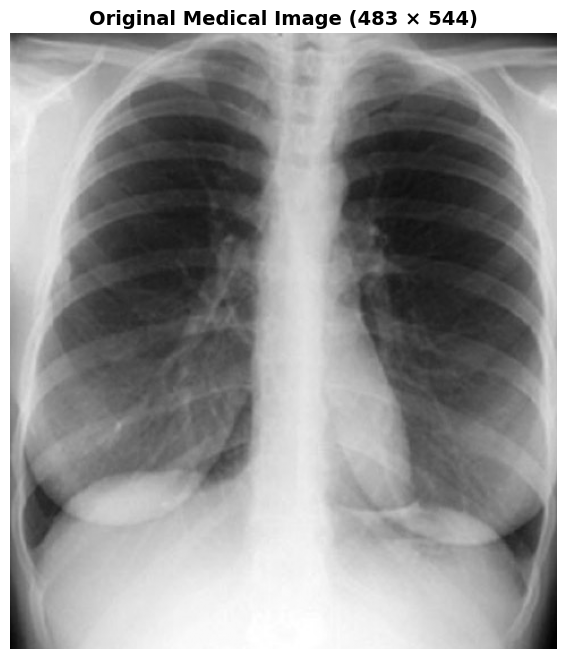

In [ ]:
plt.figure(figsize=(8, 8))

plt.imshow(image, cmap="gray")
plt.title(
    f"Original Medical Image ({width} × {height})",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")
plt.show()

Resize the Image


In [ ]:
resized_image = image.resize((224, 224))

print("Resized Image Size:", resized_image.size)

Resized Image Size: (224, 224)


Display Original and Resized Images


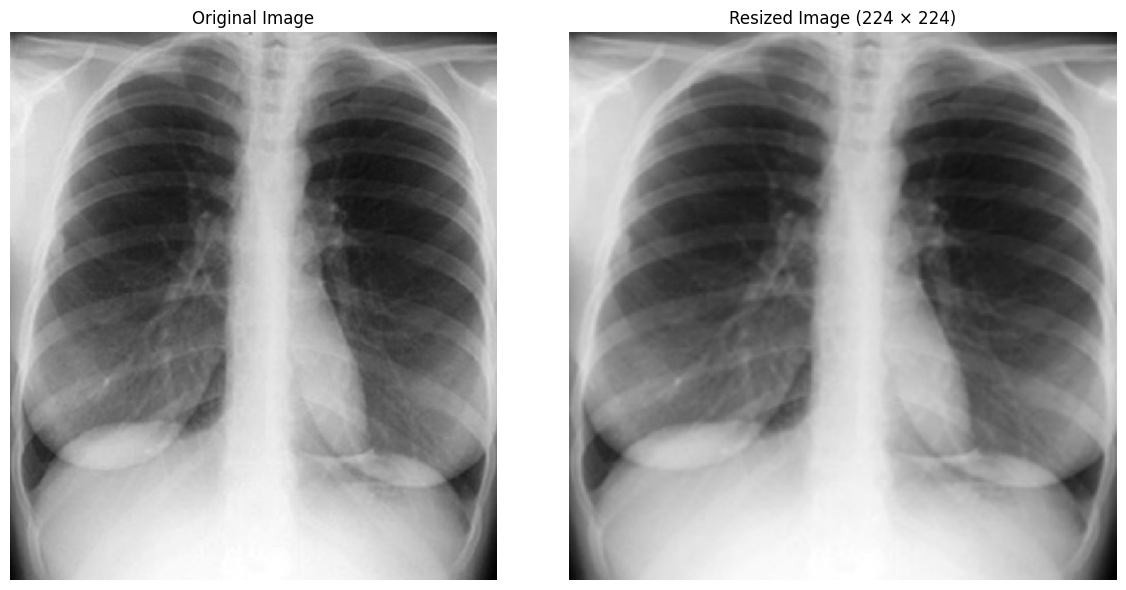

In [ ]:
plt.figure(figsize=(12, 6))

# Original image
plt.subplot(1, 2, 1)

plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")


# Resized image
plt.subplot(1, 2, 2)

plt.imshow(resized_image, cmap="gray")
plt.title("Resized Image (224 × 224)")
plt.axis("off")

plt.tight_layout()
plt.show()

Convert Image to NumPy Array


In [ ]:
import numpy as np

image_array = np.array(resized_image)

print("Image Array Shape:", image_array.shape)
print("Data Type:", image_array.dtype)
print("Minimum Pixel Value:", image_array.min())
print("Maximum Pixel Value:", image_array.max())

Image Array Shape: (224, 224)
Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 255


Normalize the Image


In [ ]:
normalized_image = image_array / 255.0

print("Normalized Pixel Range:")
print("Minimum:", normalized_image.min())
print("Maximum:", normalized_image.max())

Normalized Pixel Range:
Minimum: 0.0
Maximum: 1.0


Integration Discussion: Future Multimodal Heart Disease Model

In this project, tabular clinical data, ECG signals, and clinical text are processed separately. In a future multimodal system, these different sources could be combined to provide a more comprehensive heart disease risk assessment.bold text


1. Tabular Data: Baseline Heart Disease Risk

The tabular dataset provides structured clinical information such as:

Age

Sex

Chest pain type

Resting blood pressure

Cholesterol

Maximum heart rate

Exercise-induced angina

ST depression

These features can be used to train a machine learning model, such as Logistic Regression, to estimate a patient's baseline risk of heart disease.


Tabular Clinical Features:-> Preprocessing:-> Machine Learning Model:-> Baseline Risk Prediction


2. ECG-Derived Features: Physiological Information

ECG signals provide information about the electrical activity and rhythm of the heart. Instead of using only the raw ECG waveform, useful features could be extracted, including:

Mean RR interval

Mean heart rate

Heart rate variability

SDNN

RMSSD

Beat or rhythm-related features

These ECG-derived features could be converted into a structured feature vector and combined with the tabular clinical features.


ECG Signal:-> Beat Detection / Annotation:-> RR Interval and HRV Analysis:-> ECG Feature Vector


The ECG features could therefore augment the baseline risk prediction by adding physiological and rhythm-related information.


3. Clinical Notes: Symptom and Context Information

Clinical notes contain unstructured information that may not be fully represented in tabular data. For example, notes may describe:

Chest pain

Shortness of breath

Fatigue

Palpitations

Dizziness

Exercise tolerance

Medical history

Using simple NLP techniques, these notes can be cleaned, tokenized, and analyzed to extract clinically relevant terms.

For example:


"Patient reports chest pain and shortness of breath"
could be converted into structured features such as:

Chest Pain = 1

Shortness of Breath = 1

Fatigue = 0

Palpitations = 0

Thus, clinical text can provide additional symptom-based context to the model.


4. Future Feature Fusion Model

In a future multimodal model, features from all three sources could be combined:


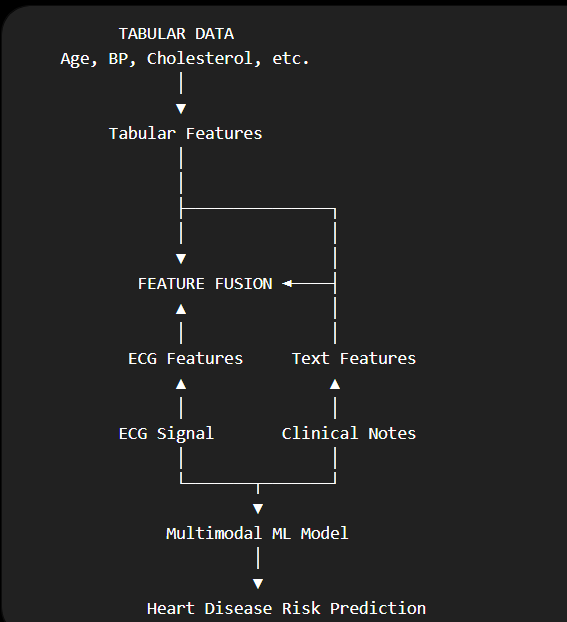


A fused feature vector could conceptually contain:

[Age,
Resting Blood Pressure,
Cholesterol,
Maximum Heart Rate,
Mean RR Interval,
SDNN,
RMSSD,
Chest Pain Present,
Shortness of Breath Present,
Palpitations Present]

This combined feature representation could then be used as input to a machine learning model such as Logistic Regression, Random Forest, XGBoost, or a neural network.


5. Important Limitation

The datasets used in this project come from different sources and are not linked at the individual patient level. Therefore, directly combining the UCI Heart Disease dataset, MIT-BIH ECG data, and synthetic clinical notes into a single training dataset would not be scientifically valid.

The current work should therefore be considered a multimodal data processing demonstration. A real fused model would require matched patient-level records containing:

Clinical and demographic data

ECG recordings from the same patients

Clinical notes associated with those patients

Consistent patient identifiers

Appropriate training and validation data

Conclusion

A future multimodal heart disease prediction system could use tabular data to estimate baseline clinical risk, ECG-derived features to add physiological and rhythm-related information, and clinical notes to provide symptom and contextual information. Feature fusion could combine these complementary sources to support a more comprehensive heart disease risk prediction model, provided that properly matched patient-level multimodal data is available.
